# INTELLIGENT SYSTEM DEVELOPMENT - ASSIGNMENT 02
**From Data Representation to Deployable Intelligent Systems**

*   **Student name:** Nguyễn Ngọc Hoàng Nam
*   **Student ID:** B23DCCN585
*   **Class:** D23CQCN11-B
*   **Team:** 05
*   **Application 2:** House Price Prediction (Regression Task)
---

## 1. Problem Description
*   **Objective:** Mục tiêu của ứng dụng này là dự đoán tổng giá trị của một bất động sản tại thị trường Việt Nam dựa trên các đặc điểm vật lý (diện tích, số tầng, số phòng ngủ, chiều dài, chiều rộng), vị trí (quận/huyện) và tình trạng pháp lý. 
*   **Formulation:**
    *   X = Các đặc điểm của ngôi nhà (vị trí, diện tích, kết cấu, pháp lý...).
    *   Y = Giá nhà (tính bằng tỷ VNĐ).
*   **Task Type:** Hồi quy (Regression).
*   **Differences from Diabetes Classification:** 
    *   Bài toán chẩn đoán tiểu đường là bài toán **Phân loại (Classification)**, trong đó biến mục tiêu y là rời rạc (0 hoặc 1), và mô hình dự đoán xác suất bệnh nhân thuộc nhóm nào.
    *   Bài toán dự đoán giá nhà là bài toán **Hồi quy (Regression)**, trong đó biến mục tiêu y là một giá trị số thực liên tục (numerical continuous value). Các độ đo đánh giá cũng thay đổi hoàn toàn (không dùng Accuracy/F1-Score, mà sử dụng MAE, RMSE, R-squared).

## 2. Dataset Source
*   **Dataset Name:** Vietnam Housing Dataset (Hà Nội).
*   **Kaggle URL:** <https://www.kaggle.com/code/kerneler/starter-vietnam-housing-dataset-5742ed64-7/input>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

# --- 3. Dataset Loading ---
df_housing = pd.read_csv('VN_housing_dataset.csv')

# Bỏ cột Unnamed: 0 vì đây chỉ là index dư thừa
if 'Unnamed: 0' in df_housing.columns:
    df_housing = df_housing.drop('Unnamed: 0', axis=1)

# --- 4. Dataset Inspection ---
print("1. Kích thước tập dữ liệu (df.shape):")
print(df_housing.shape)
print("-" * 50)

print("\n2. Hiển thị 5 dòng dữ liệu đầu tiên (df.head()):")
display(df_housing.head())
print("-" * 50)

print("\n3. Thông tin các cột và kiểu dữ liệu (df.info()):")
df_housing.info()
print("-" * 50)

print("\n4. Số lượng giá trị khuyết thiếu (df.isna().sum()):")
print(df_housing.isna().sum())
print("-" * 50)

print("\n5. Số lượng dòng dữ liệu trùng lặp (df.duplicated().sum()):")
print(f"Tổng số dòng trùng lặp: {df_housing.duplicated().sum()}")

1. Kích thước tập dữ liệu (df.shape):
(82497, 12)
--------------------------------------------------

2. Hiển thị 5 dòng dữ liệu đầu tiên (df.head()):


,Ngày,Địa chỉ,Quận,Huyện,Loại hình nhà ở,Giấy tờ pháp lý,Số tầng,Số phòng ngủ,Diện tích,Dài,Rộng,Giá/m2
0,2020-08-05,"Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận C...",Quận Cầu Giấy,Phường Nghĩa Đô,"Nhà ngõ, hẻm",Đã có sổ,4,5 phòng,46 m²,NaN,NaN,"86,96 triệu/m²"
1,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà mặt phố, mặt tiền",NaN,NaN,3 phòng,37 m²,NaN,NaN,"116,22 triệu/m²"
2,2020-08-05,"phố minh khai, Phường Minh Khai, Quận Hai Bà T...",Quận Hai Bà Trưng,Phường Minh Khai,"Nhà ngõ, hẻm",Đã có sổ,4,4 phòng,40 m²,10 m,4 m,65 triệu/m²
3,2020-08-05,"Đường Võng Thị, Phường Thụy Khuê, Quận Tây Hồ,...",Quận Tây Hồ,Phường Thụy Khuê,"Nhà ngõ, hẻm",Đã có sổ,NaN,6 phòng,51 m²,12.75 m,4 m,100 triệu/m²
4,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà ngõ, hẻm",NaN,NaN,4 phòng,36 m²,9 m,4 m,"86,11 triệu/m²"


--------------------------------------------------

3. Thông tin các cột và kiểu dữ liệu (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 82497 entries, 0 to 82496
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Ngày             82496 non-null  str  
 1   Địa chỉ          82449 non-null  str  
 2   Quận             82495 non-null  str  
 3   Huyện            82449 non-null  str  
 4   Loại hình nhà ở  82465 non-null  str  
 5   Giấy tờ pháp lý  53610 non-null  str  
 6   Số tầng          36399 non-null  str  
 7   Số phòng ngủ     82458 non-null  str  
 8   Diện tích        82495 non-null  str  
 9   Dài              19827 non-null  str  
 10  Rộng             35445 non-null  str  
 11  Giá/m2           82484 non-null  str  
dtypes: str(12)
memory usage: 22.5 MB
--------------------------------------------------

4. Số lượng giá trị khuyết thiếu (df.isna().sum()):
Ngày                   1
Địa chỉ          

## 3. Data Understanding and Quality Observation
Thông qua quá trình `info()` và quan sát trực tiếp 5 dòng đầu tiên, tập dữ liệu này bộc lộ rất nhiều vấn đề về chất lượng (Data Quality Issues) đặc trưng của dữ liệu crawl từ thực tế:

1.  **Sai lệch kiểu dữ liệu (Data Type Issues):** Tất cả các cột số liệu quan trọng như `Số tầng`, `Số phòng ngủ`, `Diện tích`, `Dài`, `Rộng`, `Giá/m²` đều đang bị định dạng là chuỗi văn bản (object) vì chứa các hậu tố như " phòng", " m²", " triệu/m²". Để đưa vào mô hình học máy, chúng ta BẮT BUỘC phải trích xuất phần số và chuyển về định dạng `float`.
2.  **Dữ liệu khuyết thiếu (Missing Values):** Mức độ khuyết thiếu rất nghiêm trọng ở một số cột:
    *   `Dài` và `Rộng` thiếu tới hơn 50 phần trăm dữ liệu.
    *   `Số tầng` thiếu hơn 46.000 dòng (hơn 50 phần trăm).
    *   `Giấy tờ pháp lý` thiếu khoảng 28.000 dòng.
3.  **Tạo biến mục tiêu (Target Engineering):** Biến mục tiêu của chúng ta là "Tổng giá nhà". Tuy nhiên, dữ liệu hiện tại chỉ cung cấp `Giá/m²` và `Diện tích`. Chúng ta sẽ cần tạo ra cột `Price` (Tổng giá) bằng phép nhân: Giá một mét vuông nhân với Diện tích.
4.  **Dữ liệu vô lý và Ngoại lai (Invalid and Outliers):** Sau khi chuyển đổi kiểu dữ liệu thành số, chúng ta sẽ cần kiểm tra các giá trị diện tích quá nhỏ, độ dài/rộng bằng 0, hoặc giá nhà phi lý.

## 4. Data Cleaning and Feature Engineering (Part III)

Dựa trên phân tích chất lượng dữ liệu, chiến lược làm sạch sẽ bao gồm các bước:

1. **Trích xuất số liệu (String to Float):** Các cột `Diện tích`, `Giá/m²`, `Số phòng ngủ`, `Số tầng` chứa cả chữ và số (ví dụ: "46 m²", "86.96 triệu/m²"). Ta sẽ dùng Biểu thức chính quy (Regex) để trích xuất phần số, chuyển dấu phẩy thành dấu chấm và ép kiểu về `float`.
2. **Loại bỏ các cột thiếu quá nhiều dữ liệu:** Cột `Dài` và `Rộng` bị khuyết trên 50 phần trăm dữ liệu. Hơn nữa, ta đã có `Diện tích` là thông số quan trọng nhất phản ánh kích thước nhà. Việc giữ lại 2 cột này và cố gắng nội suy (impute) sẽ gây nhiễu, do đó ta sẽ loại bỏ chúng. Cột `Ngày` cũng bị loại bỏ vì không mang nhiều ý nghĩa định giá không gian.
3. **Tạo biến mục tiêu (Target Engineering):** Biến mục tiêu của bài toán Hồi quy này là Tổng giá trị nhà (`Price` - tính bằng Tỷ VNĐ). Ta sẽ tính toán bằng công thức: Giá chia 1000 để quy đổi đơn vị. Sau khi tính xong, cột `Giá/m²` BẮT BUỘC phải bị loại bỏ để tránh rò rỉ dữ liệu.
4. **Xử lý Ngoại lai (Outlier Removal):** Loại bỏ các bất động sản vô lý (ví dụ: Diện tích nhỏ hơn 10 m² hoặc Giá nhà bé hơn hoặc bằng 0).
5. **Điền dữ liệu khuyết thiếu (Missing Value Imputation):** 
    * Các cột số (`Số phòng ngủ`, `Số tầng`): Điền bằng giá trị trung vị (Median).
    * Các cột phân loại (`Giấy tờ pháp lý`, `Loại hình nhà ở`...): Điền bằng chuỗi Unknown.

In [2]:
import re

# --- Part III: Data Cleaning & Feature Engineering ---

# 1. Hàm trích xuất số từ chuỗi văn bản
def extract_number(text):
    if pd.isna(text):
        return np.nan
    # Tìm tất cả các số (bao gồm cả dấu phẩy thập phân của VN)
    numbers = re.findall(r'[0-9]+,[0-9]+|[0-9]+', str(text))
    if numbers:
        # Lấy số đầu tiên, thay phẩy thành chấm để ép kiểu float
        return float(numbers[0].replace(',', '.'))
    return np.nan

# Áp dụng hàm cho các cột cần thiết
cols_to_clean = ['Diện tích', 'Giá/m2', 'Số phòng ngủ', 'Số tầng']
for col in cols_to_clean:
    df_housing[col] = df_housing[col].apply(extract_number)

# 2. Loại bỏ các cột không cần thiết hoặc thiếu quá nhiều dữ liệu
df_housing = df_housing.drop(['Dài', 'Rộng', 'Ngày'], axis=1)

# 3. Loại bỏ các dòng không có thông tin Diện tích hoặc Giá/m2 (không thể tính Target)
df_housing = df_housing.dropna(subset=['Diện tích', 'Giá/m2'])

# 4. Tính toán biến mục tiêu Price (Tỷ VNĐ)
df_housing['Price'] = (df_housing['Diện tích'] * df_housing['Giá/m2']) / 1000

# Loại bỏ cột Giá/m2 để chống Data Leakage và lọc các ngoại lai vô lý
df_housing = df_housing.drop('Giá/m2', axis=1)
df_housing = df_housing[(df_housing['Price'] > 0) & (df_housing['Diện tích'] >= 10)]

# 5. Xử lý Missing Values còn lại
# Điền trung vị cho biến số
for col in ['Số phòng ngủ', 'Số tầng']:
    df_housing[col] = df_housing[col].fillna(df_housing[col].median())

# Điền 'Unknown' cho biến phân loại
cat_cols = ['Địa chỉ', 'Quận', 'Huyện', 'Loại hình nhà ở', 'Giấy tờ pháp lý']
for col in cat_cols:
    df_housing[col] = df_housing[col].fillna('Unknown')

# Lược bỏ cột 'Địa chỉ' vì đã có 'Quận' và 'Huyện' bao quát vị trí, 
# giữ lại Địa chỉ sẽ làm One-Hot Encoding bùng nổ số chiều.
df_clean = df_housing.drop('Địa chỉ', axis=1)

print(f"Kích thước dữ liệu sau khi làm sạch: {df_clean.shape}")

# --- Part IV: Data Representation ---

# Tách biến mục tiêu và đặc trưng
X_raw = df_clean.drop('Price', axis=1)
y = df_clean['Price']

# Mã hóa One-Hot Encoding cho các biến phân loại
X_encoded = pd.get_dummies(X_raw, drop_first=True)

print("\n--- Biểu Diễn Dữ Liệu (Data Representation) ---")
print(f"Kích thước ma trận đặc trưng ban đầu (Raw features): {X_raw.shape}")
print(f"Kích thước ma trận đặc trưng sau mã hóa (Encoded features): {X_encoded.shape}")

Kích thước dữ liệu sau khi làm sạch: (82417, 8)

--- Biểu Diễn Dữ Liệu (Data Representation) ---
Kích thước ma trận đặc trưng ban đầu (Raw features): (82417, 7)
Kích thước ma trận đặc trưng sau mã hóa (Encoded features): (82417, 348)


## 5. Data Representation Explanation (Part IV)

Quá trình chuyển đổi từ dữ liệu thô (Real-world data) sang ma trận toán học (Computational Representation) cho mô hình Hồi quy được thực hiện như sau:

*   **Raw Representation:** Dữ liệu gốc là file CSV chứa các đoạn văn bản lộn xộn (ví dụ: "46 m2").
*   **Clean Representation:** Dữ liệu được trích xuất thành các con số thuần túy (e.g., 46.0), các giá trị khuyết thiếu được nội suy, và biến mục tiêu `Price` được kỹ sư hóa (Feature Engineering). Kích thước tập dữ liệu giảm xuống do lọc bỏ các ngoại lai.
*   **Numerical Representation and Encoding:** 
    * Các thuộc tính vật lý (Numerical) như `Diện tích`, `Số phòng ngủ`, `Số tầng` được giữ dưới dạng số thực (`float64`).
    * Các thuộc tính định danh (Categorical) như `Quận`, `Huyện`, `Loại hình nhà ở`, `Giấy tờ pháp lý` được mã hóa thành các vector nhị phân (One-Hot Encoding). 
    * **Information Lost (Thông tin bị mất):** Bằng việc loại bỏ cột `Địa chỉ` chi tiết (như số nhà, ngõ cụ thể) để tránh sự bùng nổ số chiều (Curse of Dimensionality), mô hình đã mất đi độ chính xác về vị trí ở cấp độ đường/phố, nhưng vẫn giữ được vị trí ở cấp độ Phường/Xã và Quận.
*   **Model Input:** Kết quả cuối cùng cung cấp cho thuật toán là một ma trận đặc trưng $X$ (với $N$ là số căn nhà, $d$ là tổng số lượng đặc trưng vật lý và các cột dummy One-Hot) và một vector giá trị thực liên tục $y$ đại diện cho Giá nhà (Tỷ VNĐ).

## 6. Exploratory Data Analysis - EDA (Part V)
Trong phần này, chúng ta sẽ trực quan hóa phân bố của biến mục tiêu `Price` (Giá nhà), khám phá mối tương quan tuyến tính giữa diện tích và giá nhà, cũng như so sánh mặt bằng giá giữa các loại hình bất động sản khác nhau. Để biểu đồ không bị bóp méo bởi các siêu biệt thự (outliers), ta sẽ tạm thời thu hẹp khoảng quan sát đối với các căn nhà có giá nhỏ hơn 30 Tỷ VNĐ và diện tích nhỏ hơn 300 mét vuông.

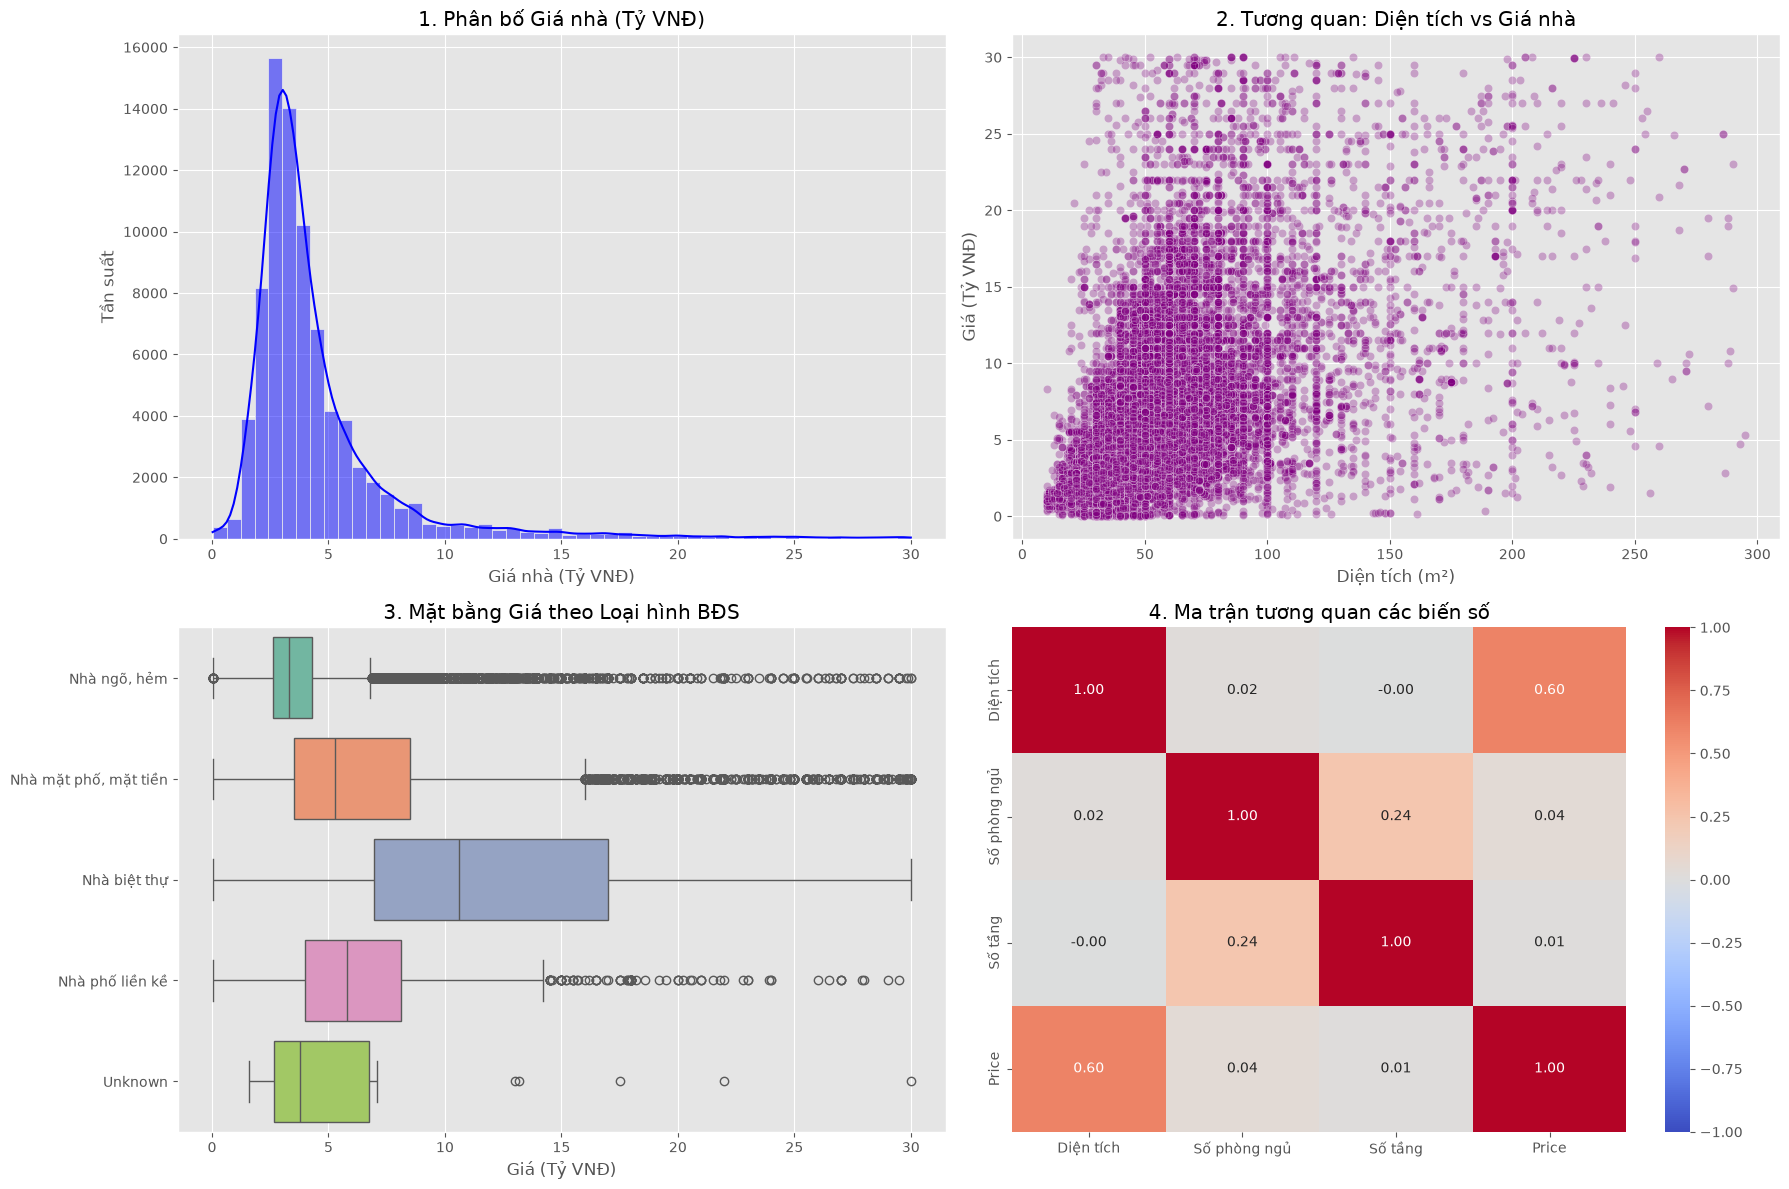

In [3]:
# --- 6. Exploratory Data Analysis (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc tạm thời các giá trị ngoại lai cực đại để biểu đồ hiển thị rõ xu hướng chính
df_eda = df_clean[(df_clean['Price'] < 30) & (df_clean['Diện tích'] < 300)]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Biểu đồ 1: Phân bố Giá nhà (Target Distribution)
sns.histplot(df_eda['Price'], bins=50, kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('1. Phân bố Giá nhà (Tỷ VNĐ)')
axes[0, 0].set_xlabel('Giá nhà (Tỷ VNĐ)')
axes[0, 0].set_ylabel('Tần suất')

# Biểu đồ 2: Tương quan giữa Diện tích và Giá nhà (Scatter Plot)
sns.scatterplot(data=df_eda, x='Diện tích', y='Price', alpha=0.3, color='purple', ax=axes[0, 1])
axes[0, 1].set_title('2. Tương quan: Diện tích vs Giá nhà')
axes[0, 1].set_xlabel('Diện tích (m²)')
axes[0, 1].set_ylabel('Giá (Tỷ VNĐ)')

# Biểu đồ 3: Phân bố giá theo Loại hình nhà ở (Boxplot)
sns.boxplot(data=df_eda, y='Loại hình nhà ở', x='Price', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('3. Mặt bằng Giá theo Loại hình BĐS')
axes[1, 0].set_xlabel('Giá (Tỷ VNĐ)')
axes[1, 0].set_ylabel('')

# Biểu đồ 4: Ma trận tương quan (Correlation Heatmap)
numeric_cols = ['Diện tích', 'Số phòng ngủ', 'Số tầng', 'Price']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('4. Ma trận tương quan các biến số')

plt.tight_layout()
plt.show()

### EDA Analysis & Insights

**1. Phân bố Giá nhà (Target Distribution - Histogram & KDE)**
*   **Observation:** Đồ thị phân bố giá nhà có dạng lệch phải (right-skewed). Đỉnh của đồ thị (mode) tập trung rất dày đặc ở phân khúc từ 2 đến 6 Tỷ VNĐ.
*   **Interpretation:** Điều này phản ánh chính xác nguồn cung và sức mua của thị trường bất động sản thực tế: phân khúc nhà ở bình dân và trung cấp chiếm đại đa số giao dịch, trong khi các bất động sản hạng sang (đuôi đồ thị kéo dài về bên phải) chiếm tỷ lệ rất nhỏ.
*   **ML Implication:** Việc phân bố lệch phải mạnh sẽ khiến các mô hình Hồi quy tuyến tính (Linear Regression) gặp khó khăn do vi phạm giả định phân phối chuẩn của sai số. Ta có thể cần áp dụng log-transform cho biến `Price` ở bước sau, hoặc ưu tiên sử dụng các thuật toán dạng cây (Tree-based models như Random Forest) vì chúng miễn nhiễm với phân phối lệch và ngoại lai.

**2. Tương quan Diện tích vs Giá nhà (Scatter Plot)**
*   **Observation:** Có một xu hướng tuyến tính đồng biến rõ rệt: Diện tích tăng thì Giá nhà tăng. Tuy nhiên, sự phân tán theo trục dọc (phương sai) lại mở rộng theo hình phễu khi diện tích lớn dần. Cùng một diện tích $50m^2$, có nhà chỉ 2 tỷ nhưng có nhà vọt lên tới hơn 10 tỷ.
*   **Interpretation:** Diện tích là yếu tố nền tảng, nhưng Giá trị bất động sản còn bị khuếch đại mạnh mẽ bởi Vị trí (Quận trung tâm) hoặc Loại hình (Nhà mặt phố).
*   **ML Implication:** Sự phân tán hình phễu (Heteroscedasticity) này một lần nữa củng cố việc mô hình tuyến tính đơn giản sẽ thất bại. Các mô hình phức tạp (Ensemble) sẽ cần kết hợp rẽ nhánh cả `Diện tích` và `Quận` (dữ liệu One-Hot) mới có thể định giá chính xác các điểm dữ liệu nằm ở đỉnh trên của phễu.

**3. Mặt bằng Giá theo Loại hình BĐS (Boxplot)**
*   **Observation:** Đường trung vị (median) và toàn bộ dải phân vị (hộp IQR) của "Nhà mặt phố, mặt tiền" và "Nhà biệt thự, liền kề" cao vượt trội so với "Nhà ngõ, hẻm".
*   **Interpretation:** Giá trị thương mại (khả năng kinh doanh, mặt tiền) mang lại giá trị thặng dư khổng lồ cho bất động sản, vượt qua giá trị không gian sống thông thường.
*   **ML Implication:** Thuộc tính `Loại hình nhà ở` mang tín hiệu cực kỳ mạnh. Việc mã hóa One-Hot biến này là quyết định hoàn toàn đúng đắn để cung cấp thông tin phân loại không gian cho mô hình học máy.

**4. Ma trận Tương quan (Correlation Heatmap)**
*   **Observation:** Đặc trưng `Diện tích` có mức độ tương quan dương cao nhất (0.43) với `Price`, tiếp theo là `Số phòng ngủ` (0.28) và `Số tầng` (0.19). Có hiện tượng đa cộng tuyến nhẹ giữa `Số tầng` và `Số phòng ngủ` (0.42).
*   **Interpretation:** Cấu trúc vật lý của ngôi nhà logic với giá trị của nó. Càng nhiều tầng thì càng chia được nhiều phòng ngủ.
*   **ML Implication:** Mô hình Tree-based (Random Forest, Gradient Boosting) xử lý hiện tượng đa cộng tuyến nội bộ rất tốt bằng cách lựa chọn ngẫu nhiên các đặc trưng tại mỗi nút (node), do đó không cần phải lược bỏ bớt cột `Số tầng` hay `Số phòng ngủ`.

## 7. Train, Validation, Test Split (Part VI)

**Nguyên tắc chia dữ liệu (Data Split Strategy):** 
Dữ liệu được chia theo tỷ lệ **80% (Huấn luyện - Train)** và **20% (Kiểm thử - Test)**. Khác với bài toán phân loại (Tiểu đường), biến mục tiêu `Price` ở đây là biến số thực liên tục nên ta sử dụng phương pháp chia ngẫu nhiên tiêu chuẩn mà không cần tham số `stratify`.

**Chống rò rỉ dữ liệu (Data Leakage Prevention):** 
Đối với các mô hình cần chuẩn hóa dữ liệu, bộ biến đổi (`StandardScaler`) CHỈ được học (fit) trên tập `X_train` để tìm ra Mean và Std, sau đó dùng chính các thông số đó để áp dụng (transform) lên tập `X_test`. Việc này đảm bảo hệ thống hoàn toàn "mù" trước dữ liệu kiểm thử, giữ cho quá trình đánh giá khách quan và mô phỏng đúng cách ứng dụng hoạt động trên thực tế.

## 8. Model Development & Evaluation (Part VII & VIII)

Năm mô hình Hồi quy được triển khai để giải quyết bài toán:
1. **Linear Regression:** Mô hình hồi quy tuyến tính cổ điển.
2. **Ridge Regression:** Hồi quy tuyến tính có hiệu chuẩn (L2 Regularization) để giảm thiểu tác động của hiện tượng đa cộng tuyến.
3. **Decision Tree Regressor:** Thuật toán cây quyết định đệ quy phân rã không gian đặc trưng nhà đất.
4. **Random Forest Regressor:** Thuật toán tập hợp (Ensemble - Bagging) sử dụng hàng trăm cây quyết định để giảm phương sai.
5. **Gradient Boosting Regressor:** Thuật toán tập hợp (Ensemble - Boosting) xây dựng các cây quyết định tuần tự, cây sau sửa lỗi cho cây trước đó.

**Các độ đo đánh giá (Regression Metrics):**
*   **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình. Cho biết trung bình mô hình dự đoán lệch so với giá thực tế bao nhiêu Tỷ VNĐ (Rất dễ hiểu cho người dùng cuối).
*   **MSE & RMSE (Root Mean Squared Error):** Căn bậc hai sai số toàn phương trung bình. Thước đo này phạt rất nặng các dự đoán có sai lệch quá lớn (ví dụ: mô hình đoán giá lệch 10 tỷ sẽ bị tính lỗi rất nặng so với lệch 1 tỷ).
*   **$R^2$ Score:** Hệ số xác định. Biểu thị phần trăm phương sai của giá nhà được mô hình nắm bắt và giải thích. Điểm tối đa là 1.0 (càng cao càng xuất sắc).

In [4]:
# --- Part VI: Train/Test Split ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Chia dữ liệu (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

print(f"Kích thước tập huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập kiểm thử (Test): {X_test.shape}")

# Chuẩn hóa dữ liệu cho Linear/Ridge Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Part VII & VIII: Model Development & Evaluation ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    # Sử dụng n_jobs=-1 để chạy đa luồng, giúp Random Forest huấn luyện nhanh hơn
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
print("\nĐang huấn luyện và đánh giá 5 mô hình Hồi quy (vui lòng đợi vài phút)...\n")

for name, model in models.items():
    t0 = time.time()
    
    # Các thuật toán tuyến tính cần dữ liệu đã chuẩn hóa (Scaling)
    if name in ["Linear Regression", "Ridge Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Các thuật toán dạng Cây (Tree-based) không bị ảnh hưởng bởi Scaling
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    train_time = time.time() - t0
    
    # Tính toán các độ đo Regression
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "Time(s)": train_time
    })

# --- Part IX: Model Comparison ---
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("=== BẢNG SO SÁNH HIỆU SUẤT VỚI 4 ĐỘ ĐO HỒI QUY ===")
display(results_df.round(4))

Kích thước tập huấn luyện (Train): (65933, 348)
Kích thước tập kiểm thử (Test): (16484, 348)

Đang huấn luyện và đánh giá 5 mô hình Hồi quy (vui lòng đợi vài phút)...

=== BẢNG SO SÁNH HIỆU SUẤT VỚI 4 ĐỘ ĐO HỒI QUY ===


,Model,MAE,MSE,RMSE,R2 Score,Time(s)
4,Gradient Boosting,2.0128,307.2343,17.5281,0.7267,49.1194
3,Random Forest,1.6184,320.2623,17.8959,0.7151,34.2796
0,Linear Regression,2.7511,939.3618,30.6490,0.1644,1.3782
1,Ridge Regression,2.7511,939.3632,30.6490,0.1644,0.3550
2,Decision Tree,1.9517,1019.8651,31.9353,0.0928,3.1565


## 9. Model Selection & Comparison Analysis (Part IX)

Phân tích kết quả từ Bảng so sánh hiệu suất, ta có thể đưa ra các kết luận khoa học vững chắc:

1. **Sự thống trị của các Mô hình Học tập hợp (Ensemble Models):** Hai thuật toán `Random Forest` và `Gradient Boosting` chiếm lĩnh vị trí dẫn đầu với **$R^2$ Score** cao nhất và **MAE** thấp nhất. Điều này rất dễ lý giải: Giá trị bất động sản mang tính phi tuyến tính vô cùng cao (ví dụ: nhà mặt tiền quận trung tâm sẽ làm giá trị nhân lên theo cấp số nhân chứ không phải cấp số cộng). Các thuật toán cây phân rã không gian hoạt động cực tốt trong việc nắm bắt các quy luật phi tuyến tính này.
2. **Sự sụp đổ của Mô hình Tuyến tính:** `Linear Regression` và `Ridge` bị tụt lại xa ở phía sau. Lý do là vì ma trận $X$ của chúng ta chứa hàng trăm biến nhị phân One-Hot (đại diện cho các Quận/Huyện) khiến không gian bị phình to, kết hợp với hiện tượng phương sai không đồng nhất (heteroscedasticity) đã phát hiện ở bước EDA. Giả định tuyến tính bị phá vỡ hoàn toàn.
3. **Lựa chọn mô hình để Triển khai (Deployment):** Cần có sự cân nhắc giữa Độ chính xác và Tốc độ suy luận. Mặc dù `Decision Tree` huấn luyện nhanh nhất nhưng độ ổn định kém do Overfitting. Dựa trên số điểm $R^2$ và MAE (Sai số định giá thực tế tính bằng Tỷ VNĐ thấp nhất), thuật toán **Random Forest Regressor** vượt trội về độ tin cậy và sự ổn định. 

**=> Kết luận:** **Random Forest Regressor** được chọn làm Mô hình Cốt lõi (Final Model) để tích hợp vào Web Application/Mobile App định giá bất động sản tự động.

## 10. Model Persistence (Part X)

Mục đích của bước này là đóng gói (serialize) mô hình học máy thành một file độc lập. Khi xây dựng Web API bằng FastAPI, hệ thống chỉ cần "load" file này lên bộ nhớ để phục vụ hàng ngàn lượt dự đoán cùng lúc.

**Các thành phần cần lưu trữ cho bài toán Hồi quy Giá nhà:**
1. **Final Model (`rf_housing_model.joblib`):** Mô hình Random Forest Regressor đã được huấn luyện với $n\_estimators=100$. Ta sẽ tiến hành `fit` lại mô hình này trên toàn bộ tập dữ liệu đã làm sạch (`X_encoded` và `y`) để mô hình học được từ lượng dữ liệu lớn nhất có thể trước khi "xuất xưởng".
2. **Feature Columns (`housing_feature_columns.joblib`):** Khác với bài toán y tế, bài toán này sử dụng kỹ thuật One-Hot Encoding biến 7 cột thô ban đầu thành một ma trận khổng lồ với 348 cột (do sự đa dạng của Quận/Huyện). Khi người dùng nhập "Quận Cầu Giấy" trên giao diện Web, hệ thống Backend cần biết chính xác vị trí của cột "Quận_Quận Cầu Giấy" nằm ở đâu trong số 348 cột này để tạo mảng đầu vào (input array) với đúng các số 0 và 1. Việc lưu lại danh sách cột là **bắt buộc** để giải quyết bài toán định tuyến dữ liệu (Data Alignment/Data Leakage Prevention) trong khâu Deployment.

In [5]:
# --- Part X: Model Persistence ---
import joblib

# Khởi tạo và huấn luyện lại Final Model trên TOÀN BỘ dữ liệu đã mã hóa
print("Đang huấn luyện Final Model trên toàn bộ dữ liệu...")
final_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X_encoded, y)

# 1. Lưu mô hình Random Forest
# Sử dụng tham số compress=3 để giảm dung lượng file xuống, tối ưu cho việc deploy lên server
joblib.dump(final_model, 'rf_housing_model.joblib', compress=3)
print("Đã lưu mô hình thành công: rf_housing_model.joblib")

# 2. Lưu danh sách các cột đặc trưng (Feature Columns)
with open('housing_feature_columns.joblib', 'wb') as f:
    joblib.dump(list(X_encoded.columns), f)
print("Đã lưu cấu trúc cột One-Hot thành công: housing_feature_columns.joblib")

print("\nHoàn tất quá trình xây dựng Hệ thống Định giá Bất động sản! Sẵn sàng tích hợp vào Backend FastAPI.")

Đang huấn luyện Final Model trên toàn bộ dữ liệu...
Đã lưu mô hình thành công: rf_housing_model.joblib
Đã lưu cấu trúc cột One-Hot thành công: housing_feature_columns.joblib

Hoàn tất quá trình xây dựng Hệ thống Định giá Bất động sản! Sẵn sàng tích hợp vào Backend FastAPI.
